# 📘 Clase 3 · Notebook 1 — Pronósticos ingenuos (*baselines*) y la métrica MAPE

**Curso de Machine Learning · Time Series Forecasting**
Basado en *Time Series Forecasting in Python* (Marco Peixeiro), **Capítulo 2**.

| | |
|---|---|
| **Datos** | `jj.csv` — ganancias por acción (EPS, en USD) trimestrales de Johnson & Johnson, 1960–1980 (84 trimestres) |
| **Tiempo estimado en casa** | 20–30 min |
| **¿Se vio en clase?** | ✅ Sí — **Demo 1** (Bloque 1) |

### 🎯 Al terminar este notebook podrás…
1. Hacer una división *train/test* **respetando el orden del tiempo**.
2. Construir 4 modelos base (*baselines*): media histórica, media del último año, último valor y *naive* estacional.
3. Calcular e interpretar el **MAPE** (error porcentual absoluto medio).
4. Explicar por qué un baseline es obligatorio antes de cualquier modelo sofisticado.

---

### ▶️ Cómo ejecutarlo

**En tu computador:** abre este notebook **desde su propia carpeta** (`CH02/`). Los datos se leen con la ruta relativa `../data/…`, así que si lo mueves de carpeta la lectura fallará.

**En Google Colab:** crea una celda al inicio y ejecuta:
```python
!git clone https://github.com/juandata-dev/TimeSeriesForecastingInPython.git
%cd TimeSeriesForecastingInPython/CH02
```

**Librerías:** `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scikit-learn`, `tqdm`.
Si te falta alguna: `pip install statsmodels scikit-learn tqdm`.

### 🗺️ Leyenda de las anotaciones
| Ícono | Significa |
|---|---|
| 🧭 | Qué hace la siguiente celda |
| 🔎 | Cómo leer el resultado que acabas de obtener |
| 💡 | Intuición o analogía para entender el concepto |
| ⚠️ | Cuidado: error común o trampa |
| 🛠️ | Cambio que hicimos al código original del libro para que funcione con versiones recientes de las librerías |
| 🤔 | Pregunta para pensar antes de seguir |

> Las celdas en inglés con `#` son los títulos originales del libro. Las anotaciones en español son de la clase.


## 0. Librerías
🧭 Importamos pandas (tablas), numpy (cálculo) y matplotlib (gráficos). La línea `pd.options.mode.chained_assignment = None` solo apaga un aviso de pandas que aparece cuando agregamos columnas a `test`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None

## 1. Cargar y mirar los datos
🧭 El archivo tiene dos columnas: `date` (inicio de cada trimestre) y `data` (Earning Per Share en dólares). Son 21 años × 4 trimestres = 84 filas.

In [3]:
df = pd.read_csv('../data/jj.csv')
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


🔎 Observa en `head()` y `tail()` que el EPS pasa de ~0.7 USD en 1960 a ~16 USD en 1980: hay una **tendencia** fuerte.

In [6]:
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [5]:
df.tail()

,date,data
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


# Plot data with train/test split 

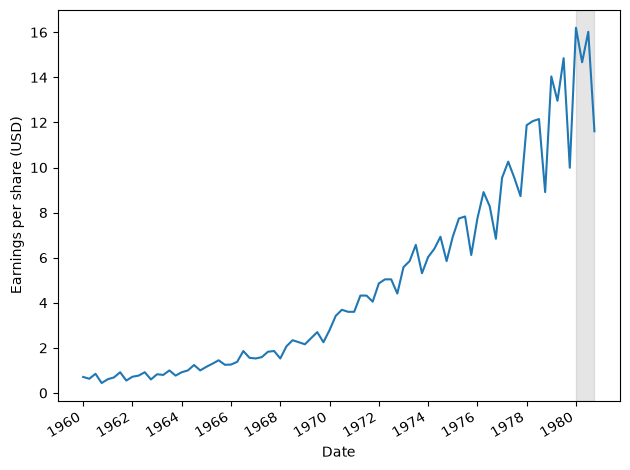

In [8]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F01_peixeiro.png', dpi=300)

🔎 **Qué ver en el gráfico** (la zona gris son los 4 trimestres de 1980 que vamos a “esconder” y pronosticar):
- **Tendencia** creciente.
- **Estacionalidad**: un patrón de subidas y bajadas que se repite cada año.
- La amplitud del patrón **crece** con el tiempo.

🤔 Antes de seguir: si tuvieras que adivinar a mano los valores de 1980, ¿qué harías?

# Split to train/test 

🧭 **División train/test temporal.** `train` = todo excepto los últimos 4 trimestres; `test` = los 4 trimestres de 1980.

⚠️ **Nunca** uses `train_test_split` con mezcla aleatoria (*shuffle*) en series de tiempo. Si mezclas, el modelo entrena con datos de 1980 para “predecir” 1975: está viendo el futuro. A eso se le llama **sesgo de anticipación** (*look-ahead bias*) y produce métricas falsamente buenas.

💡 El tamaño del test lo decide el **horizonte del negocio**: si la empresa necesita planear un año, el test es un año (4 trimestres).

In [9]:
train = df[:-4]
test = df[-4:]

# Predict historical mean 

💡 **Baseline 1 — Media histórica.** Pronosticamos, para cada trimestre de 1980, el promedio de *todo* el entrenamiento. Es el modelo más perezoso posible: ignora la tendencia y la estacionalidad.

In [10]:
historical_mean = np.mean(train['data'])
historical_mean

np.float64(4.308499987499999)

In [11]:
test.loc[:, 'pred_mean'] = historical_mean

test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


🧭 **Definimos la métrica MAPE** (*Mean Absolute Percentage Error*):

$$\text{MAPE} = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t-\hat{y}_t}{y_t}\right|$$

💡 Se lee como: *“en promedio, ¿en qué porcentaje me equivoco?”*. Es fácil de explicar a un gerente y permite comparar series de escalas distintas.

⚠️ Limitaciones: no se puede usar si hay valores reales iguales a 0 (división por cero) y se infla cuando los valores reales son muy pequeños.

In [12]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
mape_hist_mean = mape(test['data'], test['pred_mean'])
mape_hist_mean

np.float64(70.00752579965119)

🔎 **MAPE ≈ 70 %.** Terrible. La media incluye los años 60, cuando el EPS era menor a 1 USD, así que queda muy por debajo de los valores de 1980. **Lección:** la media histórica ignora la tendencia.

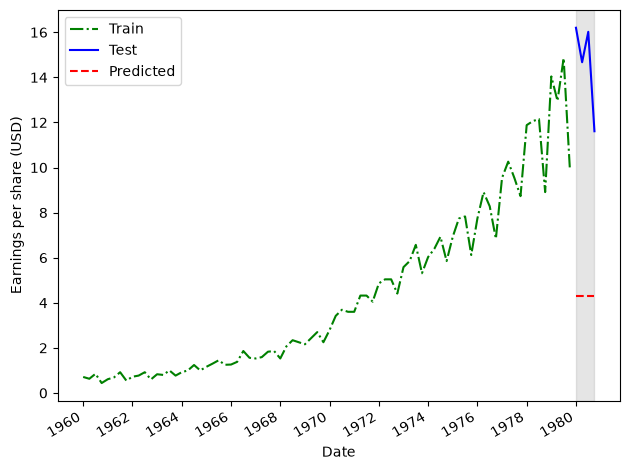

In [14]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F06_peixeiro.png', dpi=300)

# Predict last year mean 

💡 **Baseline 2 — Media del último año.** Promediamos solo los últimos 4 trimestres de entrenamiento (1979). Idea: el pasado reciente dice más sobre el futuro que el pasado lejano.

In [15]:
last_year_mean = np.mean(train['data'][-4:])
last_year_mean

np.float64(12.96)

In [16]:
test.loc[:, 'pred__last_yr_mean'] = last_year_mean

test

,date,data,pred_mean,pred__last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [18]:
mape_last_year_mean = mape(test['data'], test['pred__last_yr_mean'])
mape_last_year_mean

np.float64(15.5963680725103)

🔎 **MAPE ≈ 15.6 %.** Enorme mejora respecto al 70 %. **Lección:** en series con tendencia, lo reciente pesa más.

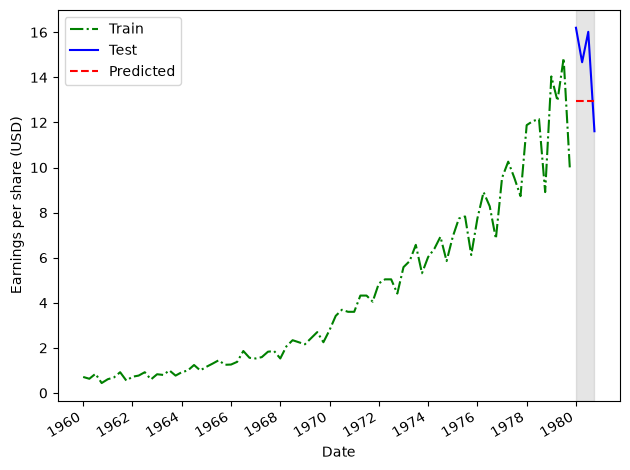

In [19]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred__last_yr_mean'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F07_peixeiro.png', dpi=300)

# Predict last know value 

💡 **Baseline 3 — Último valor conocido.** Repetimos el valor del último trimestre (Q4 de 1979 = 9.99) para los 4 trimestres de 1980.

In [20]:
last = train['data'].iloc[-1]
last

np.float64(9.99)

In [21]:
test.loc[:, 'pred_last'] = last

test

,date,data,pred_mean,pred__last_yr_mean,pred_last
80,1980-01-01,16.20,4.3085,12.96,9.99
81,1980-04-01,14.67,4.3085,12.96,9.99
82,1980-07-02,16.02,4.3085,12.96,9.99
83,1980-10-01,11.61,4.3085,12.96,9.99


In [22]:
mape_last = mape(test['data'], test['pred_last'])
mape_last

np.float64(30.457277908606535)

🔎 **MAPE ≈ 30.5 %.** ¡Peor que la media del último año! ¿Por qué? El Q4 suele ser el trimestre más bajo del año (estacionalidad). Repetirlo 4 veces subestima todo 1980.

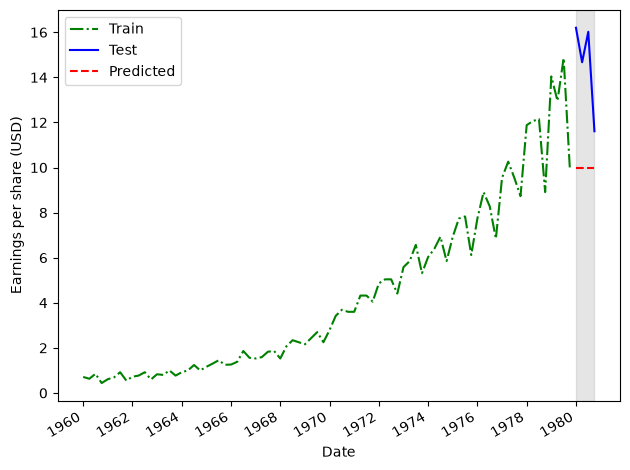

In [23]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F08_peixeiro.png', dpi=300)

# Naive seasonal forecast 

💡 **Baseline 4 — *Naive* estacional.** Cada trimestre de 1980 se pronostica con **el mismo trimestre de 1979**: Q1-1980 = Q1-1979, Q2-1980 = Q2-1979, etc. Así aprovechamos que el patrón se repite cada año.

In [24]:
test.loc[:, 'pred_last_season'] = train['data'][-4:].values

test

,date,data,pred_mean,pred__last_yr_mean,pred_last,pred_last_season
80,1980-01-01,16.20,4.3085,12.96,9.99,14.04
81,1980-04-01,14.67,4.3085,12.96,9.99,12.96
82,1980-07-02,16.02,4.3085,12.96,9.99,14.85
83,1980-10-01,11.61,4.3085,12.96,9.99,9.99


In [25]:
mape_naive_seasonal = mape(test['data'], test['pred_last_season'])
mape_naive_seasonal

np.float64(11.561658552433654)

🔎 **MAPE ≈ 11.6 %.** El mejor de los cuatro. Primera evidencia de que **capturar la estacionalidad paga**. Este número es la vara que cualquier modelo más complejo debe superar.

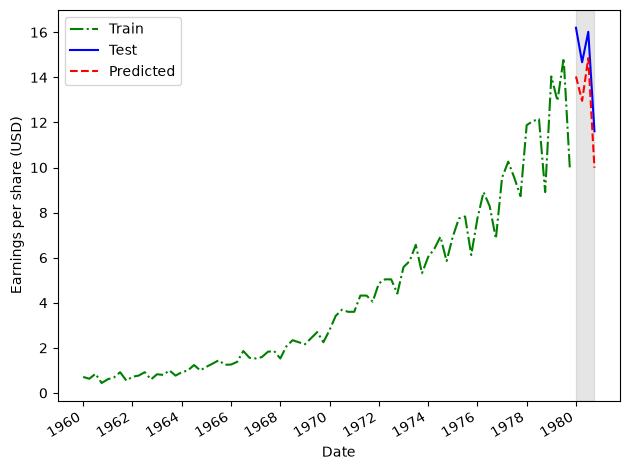

In [26]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_last_season'], 'r--', label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
ax.legend(loc=2)

plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('figures/CH02_F09_peixeiro.png', dpi=300)

🧭 Gráfico final comparando los 4 MAPE (los valores están escritos a mano a partir de los resultados anteriores).

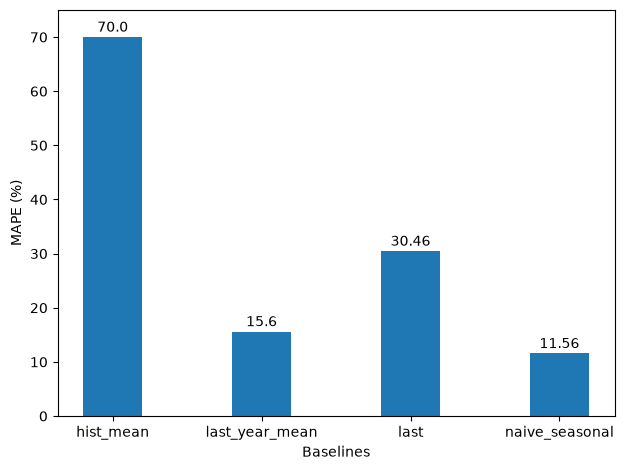

In [27]:
fig, ax = plt.subplots()

x = ['hist_mean', 'last_year_mean', 'last', 'naive_seasonal']
y = [70.00, 15.60, 30.46, 11.56]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Baselines')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 75)

for index, value in enumerate(y):
    plt.text(x=index, y=value + 1, s=str(value), ha='center')

plt.tight_layout()

plt.savefig('figures/CH02_F10_peixeiro.png', dpi=300)

---
## ✅ Resumen del notebook

| Baseline | Idea | MAPE |
|---|---|---|
| Media histórica | promedio de todo el pasado | ≈ 70.0 % |
| Media del último año | promedio de 1979 | ≈ 15.6 % |
| Último valor | repetir Q4-1979 | ≈ 30.5 % |
| **Naive estacional** | **mismo trimestre del año anterior** | **≈ 11.6 %** |

**Ideas clave**
1. **Siempre** construye un baseline antes de cualquier modelo: sin él no sabes si tu modelo complejo sirve.
2. En series de tiempo el test son **los datos más recientes** y el orden no se toca.
3. Si la serie tiene estacionalidad, el *naive* estacional suele ser un rival difícil.

🔗 **Conexión con el resto de la clase:** en el notebook del **Capítulo 7** volvemos a esta misma serie y un modelo **ARIMA** baja el MAPE a ≈ 1.7 %.

### 🏠 Ejercicios para casa
1. Cambia el horizonte a **8 trimestres** (1979–1980). ¿Cambia el ranking de los baselines?
2. Implementa el **MAE** (`sklearn.metrics.mean_absolute_error`) y compara con el MAPE. ¿Coinciden los rankings?
3. Si tuvieras **ventas diarias** de un supermercado con un patrón semanal, ¿cómo sería el *naive* estacional? (pista: ¿cuántos pasos atrás miras?)

### 🧠 Autoevaluación
- ¿Por qué no podemos mezclar (*shuffle*) los datos antes de dividir train/test?
- ¿Qué información “ve” cada baseline y qué información ignora?
